In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import torch

In [80]:
import pandas_market_calendars as mcal
import datetime


nyse = mcal.get_calendar('NYSE')
TOTAL_SECONDS_ONE_YEAR = 365*24*60*60 # total seconds

def get_market_open_close(day_stamp,no_tzinfo=True):
    early = nyse.schedule(start_date=day_stamp, end_date=day_stamp)
    if len(early) == 0:
        raise LookupError("market not open today!")
    market_open = list(early.to_dict()['market_open'].values())[0]
    market_close = list(early.to_dict()['market_close'].values())[0]
    if no_tzinfo:
        return market_open.replace(tzinfo=None),market_close.replace(tzinfo=None)
    else:
        return market_open,market_close

def get_expiry_tstamp(expiry):
    if not isinstance(expiry,str):
        return np.nan
    expiry = datetime.datetime.strptime(expiry,"%Y-%m-%d")
    _,expiry_tstamp = get_market_open_close(expiry)
    return expiry_tstamp.replace(tzinfo=None)

def get_annualized_time_to_expiration(row,expiry_mapper):
    if isinstance(row.expiry,str):
        expiry = row.expiry
    else:
        expiry = row.expiry.strftime("%Y-%m-%d")
    expiry_tstamp = expiry_mapper[expiry]
    sec_to_expiration = (expiry_tstamp-row.tstamp).total_seconds()
    atte = sec_to_expiration/TOTAL_SECONDS_ONE_YEAR
    return atte


In [81]:
from inference import load_model,device


In [104]:
model_pth_file = './workdir/spx_model_put_00009.pth'
model = load_model(model_pth_file)
h5_file = "/mnt/hd2bak/scratch/spx_w_ref_put.h5"
df = pd.read_hdf(h5_file, 'df')

3 337


In [105]:
#for date in sorted(list(df.date.unique())):
date_idx = np.random.choice(df.date)
print(date_idx)

2024-10-07T19:58:56.000000000


In [106]:
len(df.date.unique())

15495

2024-10-08T19:53:11.000000000
50
(52, 12)
(52, 3)


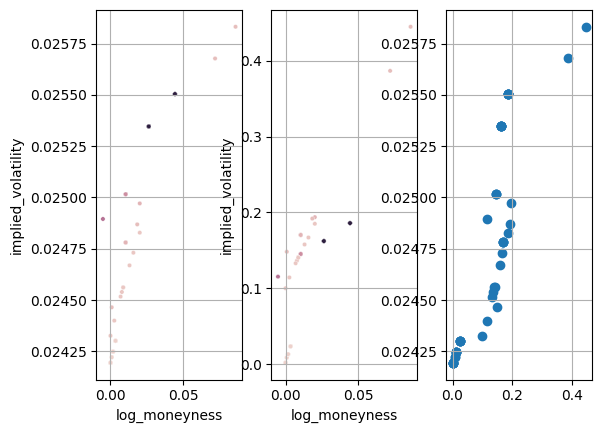

In [131]:
date_idx = np.random.choice(df.date)
print(date_idx)
print(len(df[df.date==date_idx].tau.unique()))

# ref
refdf = df[(df.date==date_idx)&(df.is_ref==1)]
z = refdf[["log_moneyness", "tau", "implied_volatility"]].to_numpy()
z = z[np.newaxis,:,:]

# grid
grid_df = df[(df.date==date_idx)&(df.is_ref==0)]
x = grid_df[["log_moneyness", "tau"]].to_numpy()
x = x[np.newaxis,:,:]

x = torch.from_numpy(x).to(device).float()
z = torch.from_numpy(z).to(device).float()
y_pred = model(z, x).squeeze(-1)
y_pred = y_pred.cpu().detach().numpy()

x = x.cpu().detach().numpy()
z = z.cpu().detach().numpy()


pred_df = pd.DataFrame({
    "log_moneyness":x[:,:,0].squeeze(),
    "tau":x[:,:,1].squeeze(),
    "implied_volatility":y_pred.squeeze()
    })

print(grid_df.shape)
print(pred_df.shape)

s = 10
plt.subplot(131)
sns.scatterplot(pred_df,x='log_moneyness',y='implied_volatility',hue='tau',s=s,legend=False)
plt.grid(True)
plt.subplot(132)
sns.scatterplot(grid_df,x='log_moneyness',y='implied_volatility',hue='tau',s=s,legend=False)
plt.grid(True)

plt.subplot(133)
plt.scatter(grid_df.implied_volatility,pred_df.implied_volatility)
plt.grid(True)

In [108]:
np.log(100/100)

np.float64(0.0)